# Filtro Casado
### Princípios de Sistemas de Conunicação - Prof. Richard
#### Aluno: Eduardo Borgonha Lopes

Este notebook apresenta a resolução da tarefa do filtro casado. 
O problema consiste em, a partir de um sinal recebido, estimar os bits transmitidos usando filtragem casada. No desenvolvimento, será apresentada a resposta ao impulso do filtro casado, a saída do filtro casado para o sinal recebido, os instantes ótimos de amostragem e os valores de y[k] nesses pontos.

Temos, do enunciado, as seguinte informações:
- Uma sequência de cinco bits foi transmitida usando pulso g(t) Manchester
e sinalização Polar, onde a[k] ∈ {+1, −1}.
- O período de símbolo é de T = 1s e o canal insere ruído.
- O arquivo sinal_recebido.txt contém uma versão
amostrada do sinal recebido r(t).
- O sinal contido no arquivo sinal_recebido.txt foi amostrado a uma taxa de
1000 amostras por segundo.


In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

Text(0.5, 0, 't (ms)')

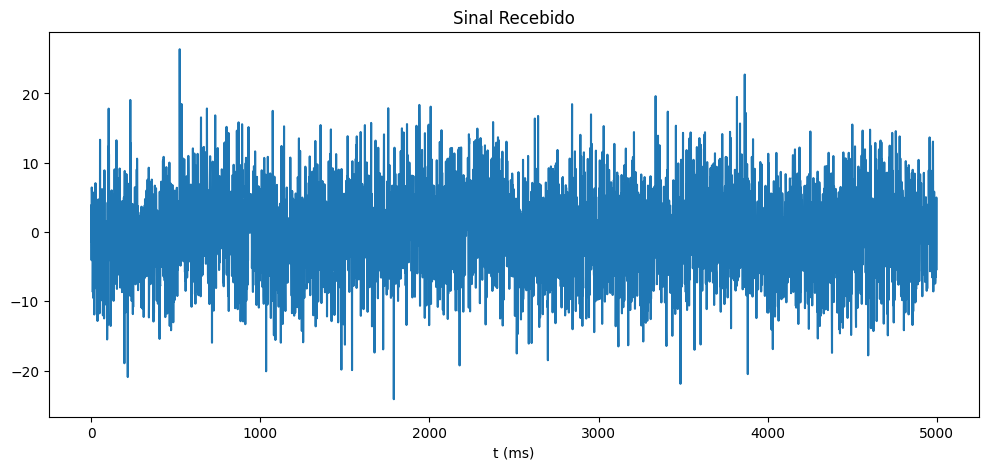

In [24]:
#carregando o sinal
sinal_recebido = np.loadtxt("sinal_recebido.txt")
plt.figure(figsize=(12, 5))
plt.plot(sinal_recebido)
plt.title("Sinal Recebido")
plt.xlabel("t (ms)")

In [3]:
T = 1 #período de 1s
fs = 1000 #taxa de amostragem
print(f"Amostragem por símbolo T . F_s: {T*fs}")

Amostragem por símbolo T . F_s: 1000


### Projeto do filtro casado:
1. Pulso Manchester tem +1 de 0 a T/2 e -1 de T/2 a -1
2. O filtro casado é dado por: h(t) = g(T - t)

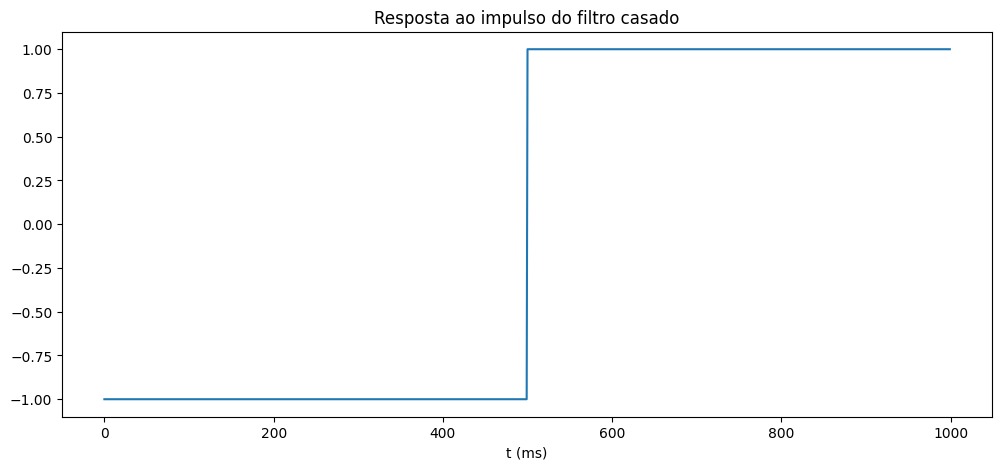

In [25]:
#para um período de 1 segundo, o filtro casado fica com a seguinte resposta ao impulso (em milisegundos):
a_s = int (T * fs) #amostras por símbolo
metade_a_s = int(a_s/2)
h_r = np.zeros(a_s)
h_r[: metade_a_s] = -1
h_r[metade_a_s : ] = 1

plt.figure(figsize=(12,5))
plt.plot(h_r)
plt.title("Resposta ao impulso do filtro casado")
plt.xlabel("t (ms)")
plt.show()

A resposta y do filtro casado é dada pela convolução (no tempo) do sinal recebido com a resposta ao impulso do filtro casado:

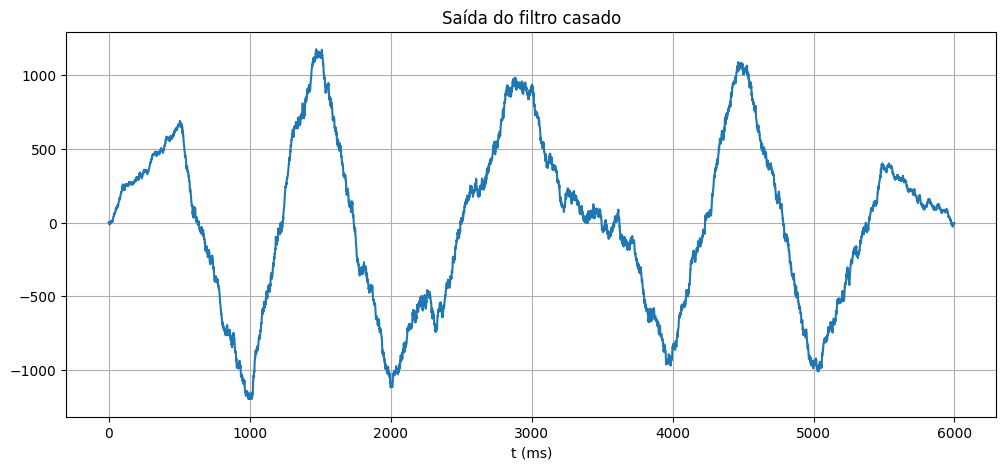

In [17]:
y = np.convolve(h_r, sinal_recebido)
plt.figure(figsize=(12,5))
plt.plot(y)
plt.title("Saída do filtro casado")
plt.xlabel("t (ms)")
plt.grid(True)
plt.show()

Temos, da teoria (slides pág. 49), que o momento ótimo para amostragem é kT + T. Vamos criar o sinal amostrado nesses instantes e também obter os respectivos y[k].

Valores y[k] amostrados: [-1174.1718, -1085.8108, 919.97, -844.9594999999998, -980.0364999999999]


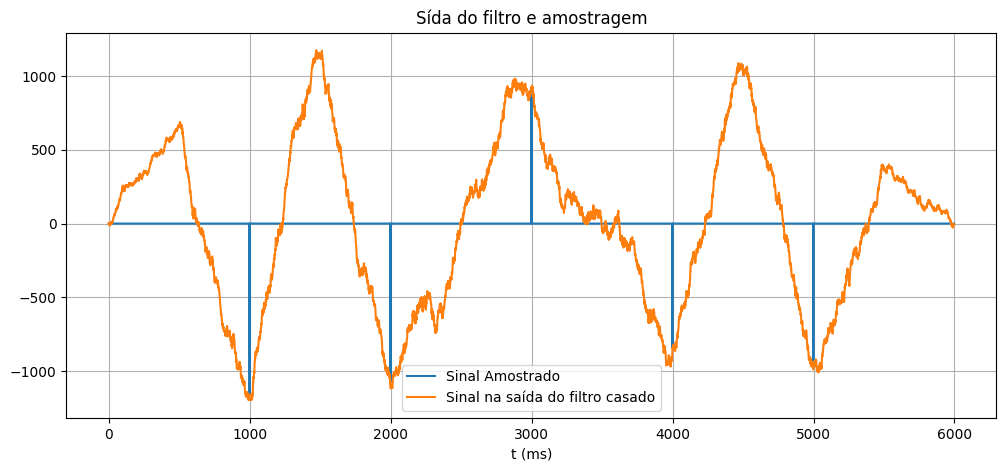

In [26]:
y_amostrado = np.zeros(y.size)
yk = []
for i in range(5):
    t = ( 1000*T* (1 + i) - 1) #indexado em 0, T é múltiplicado por 1000 pois está em ms
    y_amostrado[t] = y[t]
    yk.append(float(y[t]))

print(f"Valores y[k] amostrados: {yk}")
plt.figure(figsize=(12,5))
plt.plot(y_amostrado, label='Sinal Amostrado')
plt.plot(y, label="Sinal na saída do filtro casado")
plt.title("Sída do filtro e amostragem")
plt.xlabel("t (ms)")
plt.legend()
plt.grid(True)
plt.show()

Obter a sequência de bits recebidos é simples. Sabendo que foi utlizado Manchester e sinalização polar, basta verificar se o valor é maior ou menor que zero para decidir entre 1 e 0, respectivamente.

In [23]:
bits = []
for amostra in yk:
    bits.append(amostra > 0)
print(bits)

[False, False, True, False, False]


Fica claro, então, que a palavra binária estimada é 00100.